In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.signal import find_peaks, savgol_filter

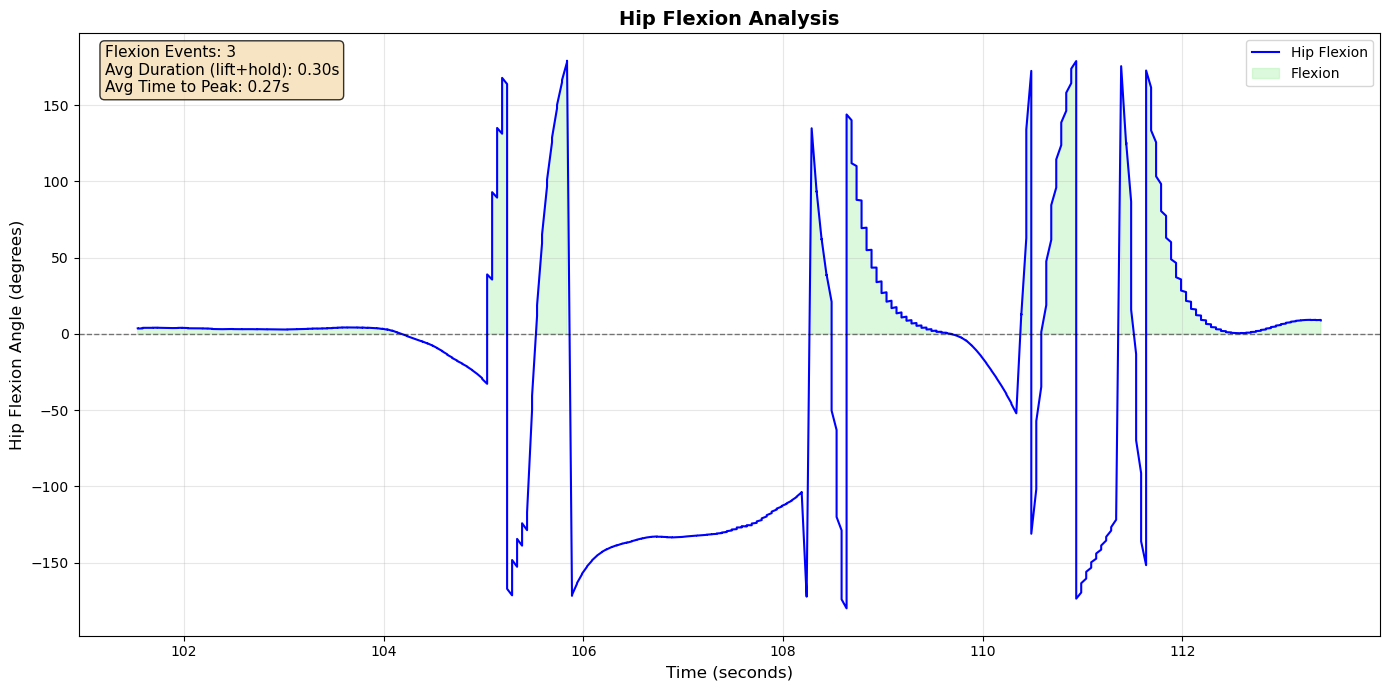

In [9]:
from scipy.signal import find_peaks

# Load data
def is_data_line(s):
    return not s.startswith("RAW") and not s.startswith("I (")

t_ms, back_deg, thigh_deg, rel_deg = np.loadtxt(
    (line for line in open("data.txt") if is_data_line(line)),
    unpack=True, dtype=float, usecols=(0, 1, 2, 3)
)
t_sec = t_ms / 1000.0

# Find flexion peaks and calculate metrics
peaks, _ = find_peaks(rel_deg, height=50, distance=100)
flexion_durations = []
time_to_peak = []

for peak_idx in peaks:
    start_idx = peak_idx
    for i in range(peak_idx - 1, -1, -1):
        if rel_deg[i] <= 0:
            start_idx = i
            break
    
    peak_angle = rel_deg[peak_idx]
    end_idx = peak_idx
    for i in range(peak_idx + 1, len(rel_deg)):
        if rel_deg[i] < peak_angle * 0.7:
            end_idx = i
            break
    
    flexion_durations.append(t_sec[end_idx] - t_sec[start_idx])
    time_to_peak.append(t_sec[peak_idx] - t_sec[start_idx])

# Plot
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.plot(t_sec, rel_deg, 'b-', linewidth=1.5, label='Hip Flexion')
ax1.fill_between(t_sec, 0, rel_deg, where=(rel_deg>0), color='lightgreen', alpha=0.3, label='Flexion')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5, linewidth=1)

# Stats box
textstr = f'Flexion Events: {len(peaks)}\n' \
          f'Avg Duration (lift+hold): {np.mean(flexion_durations):.2f}s\n' \
          f'Avg Time to Peak: {np.mean(time_to_peak):.2f}s'
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax1.set_xlabel('Time (seconds)', fontsize=12)
ax1.set_ylabel('Hip Flexion Angle (degrees)', fontsize=12)
ax1.set_title('Hip Flexion Analysis', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()
